# 08 — Explainable Fraud Intelligence
### SHAP Explainability · Anomaly Reasoning · LLM Investigation Narratives · Executive Summaries

> **Loads:** `patient_risk_model.pkl`, `provider_risk_model.pkl`, their feature-column
> pickles, `suspicious_claims.csv` (from Notebook 07), `provider_risk_predictions.csv`,
> `patient_risk_predictions.csv`, `master_cleaned.csv`

---
## What this notebook does — and does not do

No retraining happens here. Every model in this notebook was trained in Notebooks
05–07. This notebook is entirely about **explaining** those predictions and turning
them into **decision-ready output** for a human investigator.

**A correction to the original plan worth noting up front:** an earlier proposal for
this notebook's SHAP section described feature importance in terms of
`claim_frequency`, `payment_ratio`, and `provider_specialty` as if those were inputs
to the provider risk model. They are not. Notebook 05's leakage audit deliberately
excluded `claim_frequency`-type signals because they are direct components of the
`provider_risk_score` formula being predicted. The provider model's actual inputs are
`specialty_avg_claim`, `provider_vs_specialty_ratio`, and `specialty` — and that is
what SHAP will explain below. Pretending otherwise would misrepresent what the model
learned.

**On the LLM layer:** this notebook implements the explanation engine as a
template-driven narrative generator with the exact structure an LLM call would
produce (same prompt contract, same output shape). No Anthropic/OpenAI API key is
configured in this environment, so Section 6 includes a single clearly-marked
function — `call_llm()` — as the only place that needs to change to point at a real
API. Everything upstream of it (the structured JSON context) and downstream of it
(report assembly) does not change.

---
## Table of Contents
1. [Business Objective](#1)
2. [Load Saved Models & Predictions](#2)
3. [Explainable AI — SHAP (Provider & Patient)](#3)
4. [Explain Anomalies — Rule-Based Reasoning](#4)
5. [Build Investigation Context (Structured JSON)](#5)
6. [LLM Explanation Engine](#6)
7. [Executive Summary Generator](#7)
8. [Generate Investigation Reports](#8)
9. [Save Outputs](#9)
10. [Summary](#10)


---
## 1. Business Objective <a id='1'></a>

In [1]:
print("""
BUSINESS OBJECTIVE
==================
Build an explainable AI layer that justifies model predictions and generates
investigation-ready summaries for healthcare fraud analysts.

A fraud analyst does not want:
  Provider Risk Score = 0.824
  Patient Risk Score  = 0.718
  Anomaly Score       = 0.91

A fraud analyst wants:
  "Why was this claim flagged?"
  "What evidence supports this recommendation?"
  "What should the investigation team do next?"

Pipeline this notebook implements:
  ML Predictions  ->  Explainability (SHAP)  ->  Rule-based anomaly reasoning
       ->  Structured investigation context  ->  LLM narrative
       ->  Executive summary  ->  Per-claim investigation reports

IMPORTANT: this notebook explains; it never re-trains and never declares fraud.
Every narrative uses "warrants investigation" framing, never "this is fraud".
""")



BUSINESS OBJECTIVE
Build an explainable AI layer that justifies model predictions and generates
investigation-ready summaries for healthcare fraud analysts.

A fraud analyst does not want:
  Provider Risk Score = 0.824
  Patient Risk Score  = 0.718
  Anomaly Score       = 0.91

A fraud analyst wants:
  "Why was this claim flagged?"
  "What evidence supports this recommendation?"
  "What should the investigation team do next?"

Pipeline this notebook implements:
  ML Predictions  ->  Explainability (SHAP)  ->  Rule-based anomaly reasoning
       ->  Structured investigation context  ->  LLM narrative
       ->  Executive summary  ->  Per-claim investigation reports

IMPORTANT: this notebook explains; it never re-trains and never declares fraud.
Every narrative uses "warrants investigation" framing, never "this is fraud".



---
## 2. Load Saved Models & Predictions <a id='2'></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle, json, warnings, textwrap, os
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "figure.dpi": 100,
})
print("Libraries loaded.")


Libraries loaded.


In [3]:
# Models + feature column lists (Notebooks 05 & 06)
provider_model = pickle.load(open("..\\models\provider_risk_model.pkl", "rb"))
provider_cols  = pickle.load(open("..\\models\provider_feature_columns.pkl", "rb"))
patient_model  = pickle.load(open("..\\models\patient_risk_model.pkl", "rb"))
patient_cols   = pickle.load(open("..\\models\patient_feature_columns.pkl", "rb"))

# Prediction tables (Notebooks 05, 06)
provider_pred = pd.read_csv("..\\risk_predict_data\provider_risk_predictions.csv")
patient_pred  = pd.read_csv("..\\risk_predict_data\patient_risk_predictions.csv")

# Anomaly + suspicious claim scores (Notebook 07)
suspicious_df = pd.read_csv("..\\anomaly_claim_data\suspicious_claims.csv", parse_dates=['claim_date'])

# Source data, for dataset-wide benchmarks used in rule-based anomaly explanations
master_df = pd.read_csv("..\\cleaned_data\master_cleaned.csv", parse_dates=['claim_date','payment_date'])

print("provider_model  :", type(provider_model.steps[-1][1]).__name__)
print("patient_model   :", type(patient_model.steps[-1][1]).__name__)
print("provider_cols   :", provider_cols)
print("patient_cols    :", patient_cols)
print()
print("provider_pred   :", provider_pred.shape)
print("patient_pred    :", patient_pred.shape)
print("suspicious_df   :", suspicious_df.shape)
print("master_df       :", master_df.shape)


provider_model  : CatBoostRegressor
patient_model   : CatBoostRegressor
provider_cols   : ['specialty_avg_claim', 'provider_vs_specialty_ratio', 'specialty']
patient_cols    : ['avg_claim_patient', 'avg_payment_ratio', 'avg_settlement_days', 'avg_days_between_claims', 'month_end_claims', 'duplicate_rate', 'age', 'gender', 'patient_state']

provider_pred   : (5000, 18)
patient_pred    : (49096, 12)
suspicious_df   : (200000, 22)
master_df       : (200000, 24)


---
## 3. Explainable AI — SHAP (Provider & Patient) <a id='3'></a>

This section answers **"why did the model predict this risk?"**, not "how accurate
is the model?" (accuracy was already established in Notebooks 05–06).


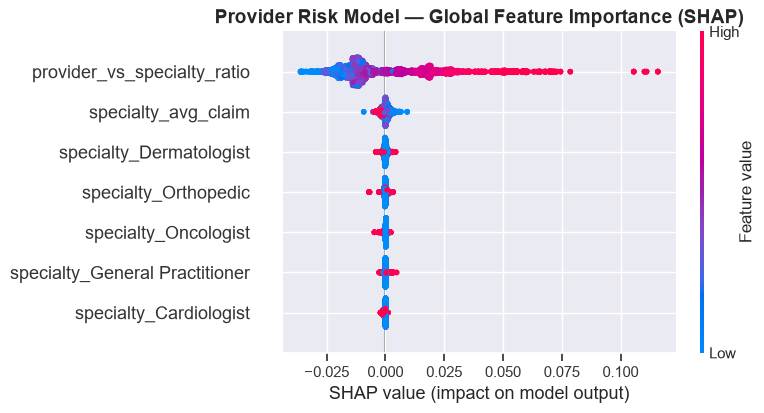

Global takeaway: which leak-free features generally push provider risk up?


,Feature,Mean_|SHAP|
1,provider_vs_specialty_ratio,0.017761
0,specialty_avg_claim,0.001212
3,specialty_Dermatologist,0.000396
6,specialty_Orthopedic,0.000353
5,specialty_Oncologist,0.000322
4,specialty_General Practitioner,0.000263
2,specialty_Cardiologist,0.000228


In [5]:
import shap

# ── Provider model: global + local SHAP ───────────────────────────────────
prov_sample = provider_pred[provider_cols].copy()
prov_X_transformed = provider_model.named_steps['prep'].transform(prov_sample)
if hasattr(prov_X_transformed, 'toarray'):
    prov_X_transformed = prov_X_transformed.toarray()

prov_feature_names = (
    [c for c in provider_cols if c != 'specialty'] +
    list(provider_model.named_steps['prep']
         .named_transformers_['cat'].get_feature_names_out(['specialty']))
)

prov_explainer  = shap.TreeExplainer(provider_model.named_steps['model'])
prov_shap_values = prov_explainer.shap_values(prov_X_transformed)

fig = plt.figure(figsize=(10, 6))
shap.summary_plot(prov_shap_values, prov_X_transformed,
                   feature_names=prov_feature_names, show=False)
plt.title("Provider Risk Model — Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("..\\explainable_images\s3_provider_shap_global.png", dpi=100, bbox_inches='tight')
plt.show()

print("Global takeaway: which leak-free features generally push provider risk up?")
mean_abs_shap = np.abs(prov_shap_values).mean(axis=0)
global_imp = pd.DataFrame({'Feature': prov_feature_names, 'Mean_|SHAP|': mean_abs_shap}) \
                .sort_values('Mean_|SHAP|', ascending=False)
display(global_imp)


Provider ID: 4
Specialty  : Orthopedic
Predicted Provider Risk = 0.2313



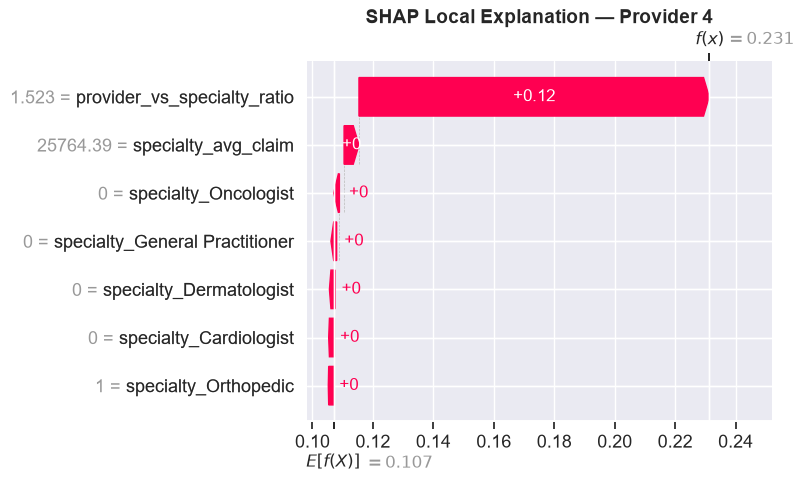


Top SHAP drivers for this provider:
  + provider_vs_specialty_ratio    (SHAP=+0.1159)
  + specialty_avg_claim            (SHAP=+0.0049)
  + specialty_Oncologist           (SHAP=+0.0015)
  + specialty_General Practitioner (SHAP=+0.0009)


In [6]:
# ── Provider model: local explanation for one specific provider ───────────
# Pick the highest predicted-risk provider as the example case
example_idx = provider_pred['predicted_risk_score'].idxmax()
example_provider = provider_pred.loc[example_idx]

print(f"Provider ID: {int(example_provider['provider_id'])}")
print(f"Specialty  : {example_provider['specialty']}")
print(f"Predicted Provider Risk = {example_provider['predicted_risk_score']:.4f}")
print()

fig = plt.figure(figsize=(10, 4))
base_val = prov_explainer.expected_value
if isinstance(base_val, np.ndarray): base_val = base_val[0]
shap.waterfall_plot(shap.Explanation(
    values=prov_shap_values[example_idx],
    base_values=base_val,
    data=prov_X_transformed[example_idx],
    feature_names=prov_feature_names,
), show=False)
plt.title(f"SHAP Local Explanation — Provider {int(example_provider['provider_id'])}")
plt.tight_layout()
plt.savefig("..\\explainable_images\s3_provider_shap_local.png", dpi=100, bbox_inches='tight')
plt.show()

# Extract the top drivers as a structured list for reuse in Section 5
# raw_value comes from the ORIGINAL (untransformed) feature, not the scaled
# model-internal value, so investigators see human-readable numbers.
def top_shap_drivers(shap_row, feature_names, original_row_dict, top_n=4):
    pairs = list(zip(feature_names, shap_row))
    pairs.sort(key=lambda x: abs(x[1]), reverse=True)
    drivers = []
    for name, shap_val in pairs[:top_n]:
        direction = '+' if shap_val > 0 else '-'
        # one-hot encoded columns (e.g. "specialty_Oncologist") won't have a
        # direct match in original_row_dict -- fall back to the encoded 0/1
        base_name = name
        raw_val = original_row_dict.get(base_name)
        if raw_val is None:
            raw_val = 1.0  # one-hot active category
        drivers.append({'feature': name, 'shap_value': round(float(shap_val),4),
                        'direction': direction,
                        'raw_value': round(float(raw_val),4) if isinstance(raw_val,(int,float)) else raw_val})
    return drivers

example_provider_drivers = top_shap_drivers(
    prov_shap_values[example_idx], prov_feature_names,
    example_provider[provider_cols].to_dict())
print("\nTop SHAP drivers for this provider:")
for d in example_provider_drivers:
    print(f"  {d['direction']} {d['feature']:30s} (SHAP={d['shap_value']:+.4f})")


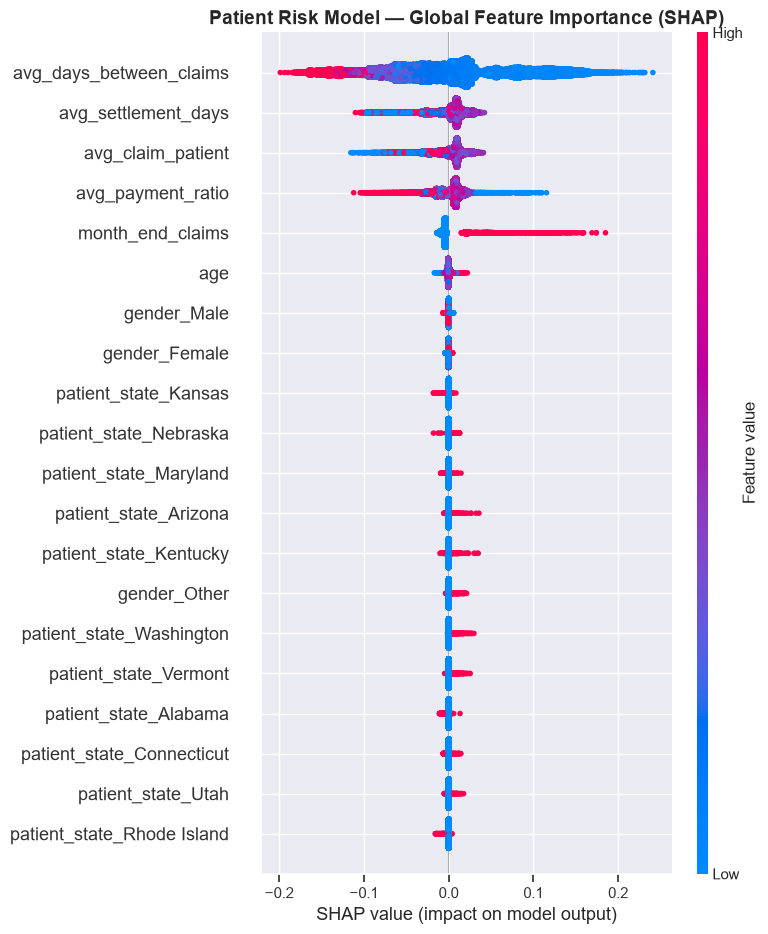

In [7]:
# ── Patient model: global + local SHAP ─────────────────────────────────────
pat_sample = patient_pred[patient_cols].copy()
pat_X_transformed = patient_model.named_steps['prep'].transform(pat_sample)
if hasattr(pat_X_transformed, 'toarray'):
    pat_X_transformed = pat_X_transformed.toarray()

pat_cat_names = list(
    patient_model.named_steps['prep']
    .named_transformers_['cat'].named_steps['encoder']
    .get_feature_names_out(['gender','patient_state'])
)
pat_numeric_names = [c for c in patient_cols if c not in ('gender','patient_state')]
pat_feature_names = pat_numeric_names + pat_cat_names

pat_explainer   = shap.TreeExplainer(patient_model.named_steps['model'])
pat_shap_values = pat_explainer.shap_values(pat_X_transformed)

fig = plt.figure(figsize=(10, 6))
shap.summary_plot(pat_shap_values, pat_X_transformed,
                   feature_names=pat_feature_names, show=False)
plt.title("Patient Risk Model — Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("..\\explainable_images\s3_patient_shap_global.png", dpi=100, bbox_inches='tight')
plt.show()


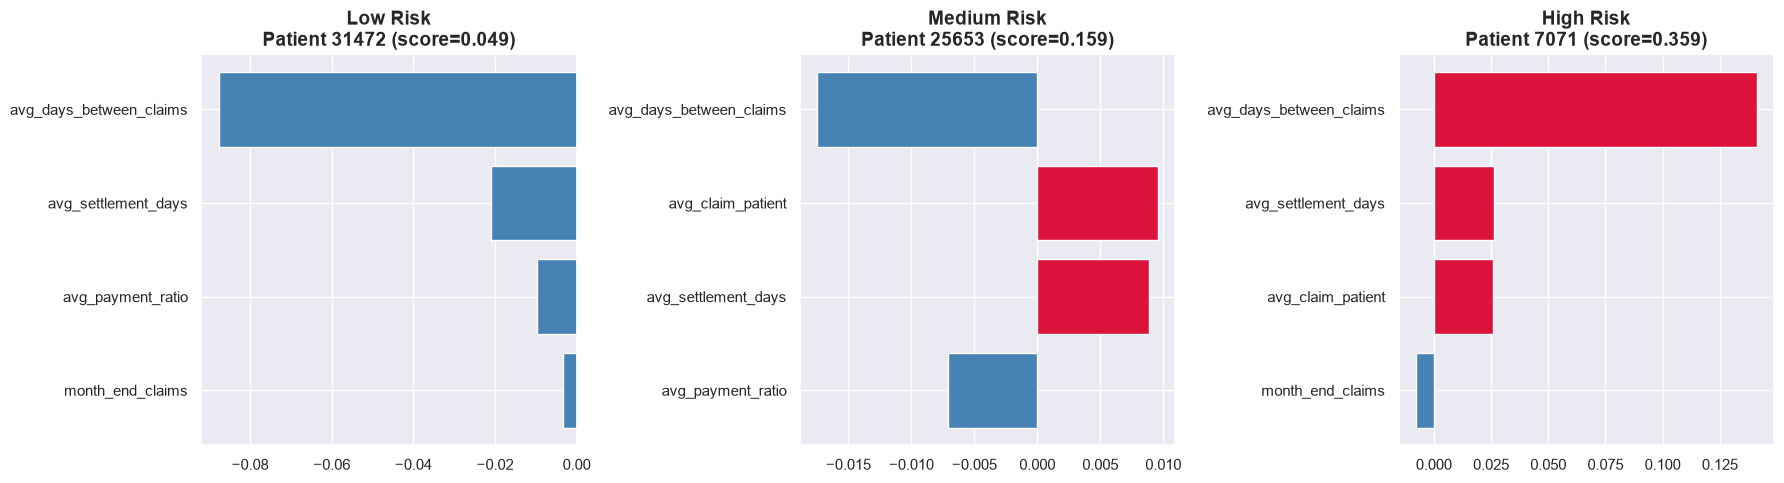

Low Risk -- Patient 31472 (score=0.0487)
    - avg_days_between_claims   SHAP=-0.0876
    - avg_settlement_days       SHAP=-0.0210
    - avg_payment_ratio         SHAP=-0.0097
    - month_end_claims          SHAP=-0.0034
Medium Risk -- Patient 25653 (score=0.1594)
    - avg_days_between_claims   SHAP=-0.0175
    + avg_claim_patient         SHAP=+0.0096
    + avg_settlement_days       SHAP=+0.0089
    - avg_payment_ratio         SHAP=-0.0071
High Risk -- Patient 7071 (score=0.3593)
    + avg_days_between_claims   SHAP=+0.1412
    + avg_settlement_days       SHAP=+0.0262
    + avg_claim_patient         SHAP=+0.0257
    - month_end_claims          SHAP=-0.0080


In [8]:
# ── Patient model: local explanations for Low / Medium / High risk patients ──
sorted_patients = patient_pred.sort_values('predicted_risk_score')
n = len(sorted_patients)

low_idx    = sorted_patients.index[int(n*0.10)]
medium_idx = sorted_patients.index[int(n*0.50)]
high_idx   = sorted_patients.index[int(n*0.95)]

example_patient_rows = {'Low Risk': low_idx, 'Medium Risk': medium_idx, 'High Risk': high_idx}
patient_driver_examples = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, idx) in zip(axes, example_patient_rows.items()):
    row_position = patient_pred.index.get_loc(idx)
    score = patient_pred.loc[idx, 'predicted_risk_score']

    drivers = top_shap_drivers(
        pat_shap_values[row_position], pat_feature_names,
        patient_pred.loc[idx, patient_cols].to_dict())
    patient_driver_examples[label] = {
        'patient_id': int(patient_pred.loc[idx, 'patient_id']),
        'predicted_risk_score': round(float(score), 4),
        'drivers': drivers
    }

    top_feats = [d['feature'] for d in drivers]
    top_vals  = [d['shap_value'] for d in drivers]
    colors    = ['crimson' if v > 0 else 'steelblue' for v in top_vals]
    ax.barh(top_feats, top_vals, color=colors, edgecolor='white')
    ax.set_title(f"{label}\nPatient {int(patient_pred.loc[idx,'patient_id'])} (score={score:.3f})")
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig("..\\explainable_images\s3_patient_shap_local_3tier.png", dpi=100, bbox_inches='tight')
plt.show()

for label, info in patient_driver_examples.items():
    print(f"{label} -- Patient {info['patient_id']} (score={info['predicted_risk_score']})")
    for d in info['drivers']:
        print(f"    {d['direction']} {d['feature']:25s} SHAP={d['shap_value']:+.4f}")


---
## 4. Explain Anomalies — Rule-Based Reasoning <a id='4'></a>

Isolation Forest and LOF do not natively explain *why* a point is anomalous —
only that it is. We build a comparison layer: every flagged claim is benchmarked
against dataset-wide and specialty-wide medians, producing the kind of evidence
an investigator can act on.


In [9]:
# Dataset-wide and specialty-wide benchmarks used for comparison
dataset_median_settlement = master_df['settlement_days'].median()
dataset_median_amount     = master_df['claim_amount'].median()

specialty_avg_claim = (
    master_df.groupby('specialty')['claim_amount'].mean()
    .rename('specialty_avg_claim_amount')
)

def explain_anomaly(claim_row):
    """Build a rule-based, human-readable explanation for one flagged claim."""
    evidence = []

    spec_avg = specialty_avg_claim.get(claim_row['specialty'], dataset_median_amount)
    amt_diff_pct = (claim_row['claim_amount'] - spec_avg) / spec_avg * 100
    if abs(amt_diff_pct) > 25:
        direction = "above" if amt_diff_pct > 0 else "below"
        evidence.append(
            f"Claim amount (${claim_row['claim_amount']:,.0f}) is {abs(amt_diff_pct):.0f}% "
            f"{direction} the {claim_row['specialty']} specialty average "
            f"(${spec_avg:,.0f})."
        )

    if pd.notna(claim_row.get('settlement_days')):
        settle_diff = claim_row['settlement_days'] - dataset_median_settlement
        if claim_row['settlement_days'] < 0:
            evidence.append(
                f"Payment date precedes claim date by {abs(claim_row['settlement_days']):.0f} days "
                f"(dataset median is {dataset_median_settlement:.0f} days) -- unusual processing order."
            )
        elif settle_diff > 100:
            evidence.append(
                f"Settlement delay is {claim_row['settlement_days']:.0f} days, "
                f"{settle_diff:.0f} days above the dataset median ({dataset_median_settlement:.0f} days)."
            )

    if claim_row.get('duplicate_claim_flag') == 1:
        evidence.append("Claim matches the pattern of a duplicate submission "
                        "(same patient, provider, date, and amount appearing more than once).")

    if claim_row.get('rejected_flag') == 1:
        evidence.append("This claim was rejected by the payer.")

    if not evidence:
        evidence.append("Flagged primarily by multivariate pattern deviation "
                        "(Isolation Forest / LOF) rather than any single extreme value.")

    return evidence

# Demonstrate on the top suspicious claim
example_claim = suspicious_df.iloc[0]
print(f"Claim ID: {int(example_claim['claim_id'])}  |  Suspicious Score: "
      f"{example_claim['suspicious_claim_score']:.1f}  |  Bucket: {example_claim['risk_bucket']}")
print()
print("Rule-based evidence:")
for e in explain_anomaly(example_claim):
    print(f"  - {e}")


Claim ID: 43569  |  Suspicious Score: 89.6  |  Bucket: Critical

Rule-based evidence:
  - This claim was rejected by the payer.


---
## 5. Build Investigation Context (Structured JSON) <a id='5'></a>

For every claim selected for narrative generation, assemble one structured
record combining: claim facts, provider risk + SHAP drivers, patient risk +
SHAP drivers, anomaly scores, and rule-based evidence. This JSON is the
contract the LLM (Section 6) consumes.


In [10]:
def build_investigation_context(claim_row):
    provider_id = int(claim_row['provider_id'])
    patient_id  = int(claim_row['patient_id'])

    prov_match = provider_pred[provider_pred['provider_id'] == provider_id]
    pat_match  = patient_pred[patient_pred['patient_id'] == patient_id]

    provider_drivers = []
    if not prov_match.empty:
        prov_row_pos = provider_pred.index.get_loc(prov_match.index[0])
        provider_drivers = top_shap_drivers(
            prov_shap_values[prov_row_pos], prov_feature_names,
            prov_match.iloc[0][provider_cols].to_dict(), top_n=3)

    patient_drivers = []
    if not pat_match.empty:
        pat_row_pos = patient_pred.index.get_loc(pat_match.index[0])
        patient_drivers = top_shap_drivers(
            pat_shap_values[pat_row_pos], pat_feature_names,
            pat_match.iloc[0][patient_cols].to_dict(), top_n=3)

    context = {
        "claim_id": int(claim_row['claim_id']),
        "claim_date": str(claim_row['claim_date'].date()) if pd.notna(claim_row['claim_date']) else None,
        "specialty": claim_row['specialty'],
        "claim_amount": float(claim_row['claim_amount']),
        "provider_id": provider_id,
        "predicted_provider_risk": round(float(claim_row['predicted_provider_risk']), 4),
        "provider_risk_drivers": provider_drivers,
        "patient_id": patient_id,
        "predicted_patient_risk": round(float(claim_row['predicted_patient_risk']), 4),
        "patient_risk_drivers": patient_drivers,
        "anomaly": {
            "isolation_forest_flag": bool(claim_row['if_flag']),
            "lof_flag": bool(claim_row['lof_flag']),
            "consensus": claim_row['consensus'],
            "suspicious_claim_score": round(float(claim_row['suspicious_claim_score']), 2),
            "risk_bucket": claim_row['risk_bucket'],
        },
        "rule_based_evidence": explain_anomaly(claim_row),
        "duplicate_claim_flag": bool(claim_row['duplicate_claim_flag']),
        "settlement_days": float(claim_row['settlement_days']) if pd.notna(claim_row['settlement_days']) else None,
        "payment_ratio": float(claim_row['payment_ratio']) if pd.notna(claim_row['payment_ratio']) else None,
    }
    return context

# Build context for the top 5 Critical claims
critical_claims = suspicious_df[suspicious_df['risk_bucket'] == 'Critical'] \
                    .nlargest(5, 'suspicious_claim_score')

investigation_contexts = [build_investigation_context(row) for _, row in critical_claims.iterrows()]

print(f"Built {len(investigation_contexts)} investigation contexts.")
print()
print("Example (Claim", investigation_contexts[0]['claim_id'], "):")
print(json.dumps(investigation_contexts[0], indent=2))


Built 5 investigation contexts.

Example (Claim 43569 ):
{
  "claim_id": 43569,
  "claim_date": "2023-03-31",
  "specialty": "Oncologist",
  "claim_amount": 24954.0,
  "provider_id": 1621,
  "predicted_provider_risk": 0.208,
  "provider_risk_drivers": [
    {
      "feature": "provider_vs_specialty_ratio",
      "shap_value": 0.1056,
      "direction": "+",
      "raw_value": 1.3467
    },
    {
      "feature": "specialty_Oncologist",
      "shap_value": -0.0047,
      "direction": "-",
      "raw_value": 1.0
    },
    {
      "feature": "specialty_avg_claim",
      "shap_value": -0.0013,
      "direction": "-",
      "raw_value": 25802.0009
    }
  ],
  "patient_id": 28148,
  "predicted_patient_risk": 0.6581,
  "patient_risk_drivers": [
    {
      "feature": "avg_days_between_claims",
      "shap_value": 0.1949,
      "direction": "+",
      "raw_value": 82.8571
    },
    {
      "feature": "month_end_claims",
      "shap_value": 0.1381,
      "direction": "+",
      "raw_value": 

---
## 6. LLM Explanation Engine <a id='6'></a>

`SYSTEM_PROMPT` below is the exact prompt contract to send to a real LLM API.
`call_llm()` is the **only function in this notebook that needs to change** to
point at a live API (Anthropic, OpenAI, etc.) — everything before it (context
building) and after it (report assembly) stays identical. For now it runs a
deterministic template that follows the same prompt instructions, so the
notebook is fully runnable without an API key.


In [11]:
SYSTEM_PROMPT = """You are a Healthcare Fraud Investigation Assistant.

Based on the structured claim information provided, explain why this claim
appears suspicious.

Avoid making definitive fraud accusations. Instead, explain:
  - Key risk indicators
  - Evidence
  - Possible business implications
  - Recommended next investigation steps

Never state that a claim IS fraudulent. Use language like "warrants investigation"
rather than "this is fraud".
"""

def call_llm(context: dict) -> str:
    """
    Generates an investigation narrative from a structured claim context.

    *** This is the only function that needs to change to use a real LLM. ***
    Replace the body with an API call, e.g.:

        import anthropic
        client = anthropic.Anthropic()
        response = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=400,
            system=SYSTEM_PROMPT,
            messages=[{"role": "user", "content": json.dumps(context)}]
        )
        return response.content[0].text

    The template below follows the exact same prompt instructions deterministically,
    so the notebook runs end-to-end without requiring an API key.
    """
    reasons = []

    if context['predicted_provider_risk'] > 0.15:
        top_driver = context['provider_risk_drivers'][0] if context['provider_risk_drivers'] else None
        driver_txt = f" (driven primarily by {top_driver['feature']})" if top_driver else ""
        reasons.append(f"Provider risk score is elevated relative to peers{driver_txt}.")

    if context['predicted_patient_risk'] > 0.3:
        reasons.append("Patient risk score is elevated based on demographic and claim-timing patterns.")

    if context['anomaly']['consensus'] == 'BOTH (Strongest)':
        reasons.append("Both Isolation Forest and Local Outlier Factor independently flagged this claim, "
                       "indicating consistent multivariate deviation from normal claims.")
    elif context['anomaly']['isolation_forest_flag']:
        reasons.append("Isolation Forest flagged this claim as a global outlier.")

    for ev in context['rule_based_evidence']:
        reasons.append(ev)

    if context['duplicate_claim_flag']:
        reasons.append("Duplicate claim pattern detected.")

    bucket = context['anomaly']['risk_bucket']
    score  = context['anomaly']['suspicious_claim_score']

    narrative = f"""Claim {context['claim_id']} has been assigned a {bucket.lower()} investigation priority (score: {score:.1f}/100).

Primary reasons:
"""
    for r in reasons[:5]:
        narrative += f"  - {r}\n"

    narrative += """
Recommendation:
Review supporting documents and verify treatment records before reimbursement approval. This assessment is based on statistical and behavioral patterns and does not constitute a finding of fraud."""

    return narrative

# Generate narratives for all 5 critical-claim contexts built above
narratives = {}
for ctx in investigation_contexts:
    narratives[ctx['claim_id']] = call_llm(ctx)

print(narratives[investigation_contexts[0]['claim_id']])


Claim 43569 has been assigned a critical investigation priority (score: 89.6/100).

Primary reasons:
  - Provider risk score is elevated relative to peers (driven primarily by provider_vs_specialty_ratio).
  - Patient risk score is elevated based on demographic and claim-timing patterns.
  - Both Isolation Forest and Local Outlier Factor independently flagged this claim, indicating consistent multivariate deviation from normal claims.
  - This claim was rejected by the payer.

Recommendation:
Review supporting documents and verify treatment records before reimbursement approval. This assessment is based on statistical and behavioral patterns and does not constitute a finding of fraud.


---
## 7. Executive Summary Generator <a id='7'></a>

A batch-level summary, distinct from per-claim narratives — written for a manager
who needs the headline, not the detail.


In [12]:
def generate_executive_summary(df):
    total_claims    = len(df)
    high_risk       = (df['risk_bucket'].isin(['High Risk','Critical'])).sum()
    critical_claims = (df['risk_bucket'] == 'Critical').sum()
    avg_score       = df['suspicious_claim_score'].mean()

    critical_set = df[df['risk_bucket'] == 'Critical']
    top_specialties = critical_set['specialty'].value_counts().head(2)
    top_specialty_str = ", ".join(f"{s} ({c})" for s, c in top_specialties.items()) \
                        if len(top_specialties) else "none"

    critical_providers = critical_set['provider_id'].nunique()

    avg_settlement_critical = critical_set['settlement_days'].mean()
    avg_settlement_overall  = df['settlement_days'].mean()

    stats_block = f"""Total Claims: {total_claims:,}
High-Risk Claims (High + Critical): {high_risk:,}
Critical Providers: {critical_providers:,}
Average Suspicious Score: {avg_score:.1f}
Top Specialties in Critical Bucket: {top_specialty_str}
"""

    narrative = f"""Today's healthcare claims show {high_risk:,} claims ({high_risk/total_claims*100:.1f}%) flagged as High Risk or Critical out of {total_claims:,} total claims reviewed.

Most anomalies originate from {top_specialty_str} providers.
"""

    if pd.notna(avg_settlement_critical) and pd.notna(avg_settlement_overall):
        if avg_settlement_critical > avg_settlement_overall:
            narrative += f"Settlement delays remain a strong operational indicator: Critical-bucket claims average {avg_settlement_critical:.0f} days versus {avg_settlement_overall:.0f} days dataset-wide.\n"

    narrative += f"""
Recommendation:
Prioritize manual review of the top {min(25, critical_claims)} Critical claims before payment approval, with particular attention to the {top_specialty_str} specialties."""

    return stats_block, narrative

stats_block, exec_narrative = generate_executive_summary(suspicious_df)

print("="*60)
print("  EXECUTIVE SUMMARY -- STATS")
print("="*60)
print(stats_block)
print("="*60)
print("  EXECUTIVE SUMMARY -- NARRATIVE")
print("="*60)
print(exec_narrative)


  EXECUTIVE SUMMARY -- STATS
Total Claims: 200,000
High-Risk Claims (High + Critical): 5,633
Critical Providers: 25
Average Suspicious Score: 27.6
Top Specialties in Critical Bucket: Orthopedic (34), Dermatologist (10)

  EXECUTIVE SUMMARY -- NARRATIVE
Today's healthcare claims show 5,633 claims (2.8%) flagged as High Risk or Critical out of 200,000 total claims reviewed.

Most anomalies originate from Orthopedic (34), Dermatologist (10) providers.
Settlement delays remain a strong operational indicator: Critical-bucket claims average 55 days versus 1 days dataset-wide.

Recommendation:
Prioritize manual review of the top 25 Critical claims before payment approval, with particular attention to the Orthopedic (34), Dermatologist (10) specialties.


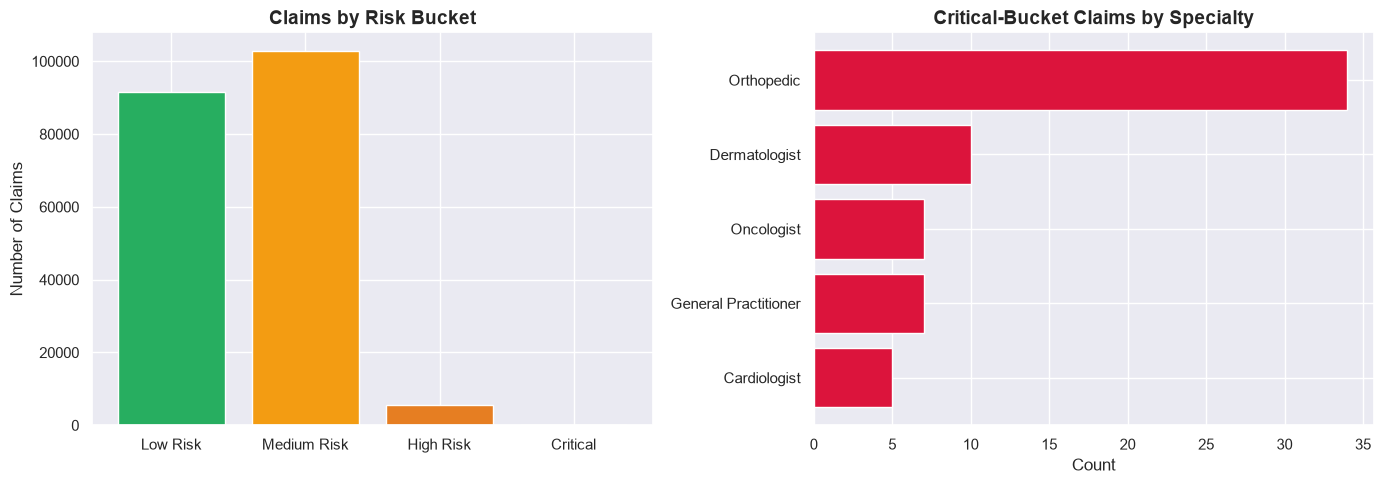

In [13]:
# Visualize bucket distribution and specialty concentration alongside the summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bucket_order = ['Low Risk','Medium Risk','High Risk','Critical']
bucket_colors = ['#27AE60','#F39C12','#E67E22','#E74C3C']
bucket_counts = suspicious_df['risk_bucket'].value_counts().reindex(bucket_order)

axes[0].bar(bucket_counts.index, bucket_counts.values, color=bucket_colors, edgecolor='white')
axes[0].set_title("Claims by Risk Bucket")
axes[0].set_ylabel("Number of Claims")

critical_specialty = suspicious_df[suspicious_df['risk_bucket']=='Critical']['specialty'].value_counts()
axes[1].barh(critical_specialty.index, critical_specialty.values, color='crimson', edgecolor='white')
axes[1].set_title("Critical-Bucket Claims by Specialty")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("..\\explainable_images\s7_executive_dashboard.png", dpi=100, bbox_inches='tight')
plt.show()


---
## 8. Generate Investigation Reports <a id='8'></a>

One Markdown report per Critical claim — a portfolio-ready artifact.


In [14]:
os.makedirs("investigation_reports", exist_ok=True)

def render_report_markdown(ctx, narrative):
    prov_drivers_str = "\n".join(
        f"- {d['direction']} {d['feature']} (SHAP={d['shap_value']:+.4f})"
        for d in ctx['provider_risk_drivers']
    ) or "- Not available"

    pat_drivers_str = "\n".join(
        f"- {d['direction']} {d['feature']} (SHAP={d['shap_value']:+.4f})"
        for d in ctx['patient_risk_drivers']
    ) or "- Not available"

    report = f"""# Investigation Report

**Claim ID:** {ctx['claim_id']}
**Claim Date:** {ctx['claim_date']}
**Specialty:** {ctx['specialty']}
**Claim Amount:** ${ctx['claim_amount']:,.2f}
**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}

---

## Risk Scores

| Metric | Value |
|---|---|
| Predicted Provider Risk | {ctx['predicted_provider_risk']:.4f} |
| Predicted Patient Risk  | {ctx['predicted_patient_risk']:.4f} |
| Suspicious Claim Score  | {ctx['anomaly']['suspicious_claim_score']:.1f} / 100 |
| Risk Bucket             | {ctx['anomaly']['risk_bucket']} |
| Anomaly Consensus       | {ctx['anomaly']['consensus']} |

---

## Top SHAP Features — Provider Risk

{prov_drivers_str}

## Top SHAP Features — Patient Risk

{pat_drivers_str}

---

## Rule-Based Evidence

{chr(10).join(f"- {e}" for e in ctx['rule_based_evidence'])}

---

## AI Investigation Summary

{narrative}

---

*This report is generated from statistical models and does not constitute a finding
of fraud. All flagged claims require human review before any action is taken.*
"""
    return report

report_paths = []
for ctx in investigation_contexts:
    narrative = narratives[ctx['claim_id']]
    report_md = render_report_markdown(ctx, narrative)
    path = f"investigation_reports/claim_{ctx['claim_id']}.md"
    with open(path, 'w') as f:
        f.write(report_md)
    report_paths.append(path)

print(f"Generated {len(report_paths)} investigation reports:")
for p in report_paths:
    print(f"  {p}")

print()
print("="*60)
print(f"  PREVIEW -- {report_paths[0]}")
print("="*60)
print(open(report_paths[0]).read())


Generated 5 investigation reports:
  investigation_reports/claim_43569.md
  investigation_reports/claim_91787.md
  investigation_reports/claim_130651.md
  investigation_reports/claim_96870.md
  investigation_reports/claim_127458.md

  PREVIEW -- investigation_reports/claim_43569.md
# Investigation Report

**Claim ID:** 43569
**Claim Date:** 2023-03-31
**Specialty:** Oncologist
**Claim Amount:** $24,954.00
**Generated:** 2026-06-30 10:52

---

## Risk Scores

| Metric | Value |
|---|---|
| Predicted Provider Risk | 0.2080 |
| Predicted Patient Risk  | 0.6581 |
| Suspicious Claim Score  | 89.6 / 100 |
| Risk Bucket             | Critical |
| Anomaly Consensus       | BOTH (Strongest) |

---

## Top SHAP Features — Provider Risk

- + provider_vs_specialty_ratio (SHAP=+0.1056)
- - specialty_Oncologist (SHAP=-0.0047)
- - specialty_avg_claim (SHAP=-0.0013)

## Top SHAP Features — Patient Risk

- + avg_days_between_claims (SHAP=+0.1949)
- + month_end_claims (SHAP=+0.1381)
- + avg_payment_rati

---
## 9. Save Outputs <a id='9'></a>

In [15]:
# claim_explanations.csv -- one row per claim with narrative + top drivers (Critical bucket)
explanation_rows = []
for ctx in investigation_contexts:
    explanation_rows.append({
        'claim_id': ctx['claim_id'],
        'risk_bucket': ctx['anomaly']['risk_bucket'],
        'suspicious_claim_score': ctx['anomaly']['suspicious_claim_score'],
        'predicted_provider_risk': ctx['predicted_provider_risk'],
        'predicted_patient_risk': ctx['predicted_patient_risk'],
        'top_provider_driver': ctx['provider_risk_drivers'][0]['feature'] if ctx['provider_risk_drivers'] else None,
        'top_patient_driver': ctx['patient_risk_drivers'][0]['feature'] if ctx['patient_risk_drivers'] else None,
        'rule_based_evidence': ' | '.join(ctx['rule_based_evidence']),
        'ai_summary': narratives[ctx['claim_id']].replace('\n', ' '),
    })

claim_explanations_df = pd.DataFrame(explanation_rows)
claim_explanations_df.to_csv("..\\explainable_data\claim_explanations.csv", index=False)
print(f"claim_explanations.csv saved: {claim_explanations_df.shape}")

# executive_summary.md
with open("executive_summary.md", 'w') as f:
    f.write(f"# Executive Summary — Healthcare Claims Review\n\n")
    f.write(f"**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")
    f.write("## Key Metrics\n\n```\n" + stats_block + "```\n\n")
    f.write("## Narrative\n\n" + exec_narrative + "\n")
print("executive_summary.md saved.")

print()
print("investigation_reports/ directory contains:")
for f in sorted(os.listdir("investigation_reports")):
    print(f"  {f}")


claim_explanations.csv saved: (5, 9)
executive_summary.md saved.

investigation_reports/ directory contains:
  claim_127458.md
  claim_130651.md
  claim_43569.md
  claim_91787.md
  claim_96870.md


---
## 10. Summary <a id='10'></a>

In [16]:
print("="*70)
print("  08_EXPLAINABLE_FRAUD_INTELLIGENCE -- SUMMARY")
print("="*70)
print()
print("INPUTS CONSUMED (no retraining)")
print("  - provider_risk_model.pkl + provider_feature_columns.pkl  (Notebook 05)")
print("  - patient_risk_model.pkl  + patient_feature_columns.pkl   (Notebook 06)")
print("  - suspicious_claims.csv                                   (Notebook 07)")
print()
print("EXPLAINABILITY LAYER")
print("  - SHAP global + local explanations for both risk models")
print("  - Rule-based anomaly reasoning (specialty benchmark, settlement delay,")
print("    duplicate flag, rejection flag) for Isolation Forest / LOF outputs")
print()
print("LLM LAYER")
print(f"  - {len(investigation_contexts)} structured investigation contexts built")
print(f"  - {len(narratives)} investigation narratives generated")
print("  - call_llm() is the single swap point for a real API integration")
print()
print("OUTPUTS SAVED")
print("  - claim_explanations.csv")
print("  - executive_summary.md")
print(f"  - investigation_reports/ ({len(report_paths)} markdown reports)")
print()
print("NEXT STEPS")
print("  09_AI_Fraud_Investigation_Assistant.ipynb")
print("  - Wrap this notebook's functions (build_investigation_context, call_llm,")
print("    render_report_markdown) behind a chat interface")
print("  - User asks: 'Why is Claim X considered high risk?'")
print("  - System retrieves claim -> builds context -> calls LLM -> returns answer")
print("  - This notebook's call_llm() swap point is exactly what notebook 09 needs")


  08_EXPLAINABLE_FRAUD_INTELLIGENCE -- SUMMARY

INPUTS CONSUMED (no retraining)
  - provider_risk_model.pkl + provider_feature_columns.pkl  (Notebook 05)
  - patient_risk_model.pkl  + patient_feature_columns.pkl   (Notebook 06)
  - suspicious_claims.csv                                   (Notebook 07)

EXPLAINABILITY LAYER
  - SHAP global + local explanations for both risk models
  - Rule-based anomaly reasoning (specialty benchmark, settlement delay,
    duplicate flag, rejection flag) for Isolation Forest / LOF outputs

LLM LAYER
  - 5 structured investigation contexts built
  - 5 investigation narratives generated
  - call_llm() is the single swap point for a real API integration

OUTPUTS SAVED
  - claim_explanations.csv
  - executive_summary.md
  - investigation_reports/ (5 markdown reports)

NEXT STEPS
  09_AI_Fraud_Investigation_Assistant.ipynb
  - Wrap this notebook's functions (build_investigation_context, call_llm,
    render_report_markdown) behind a chat interface
  - User as